In [1]:
!pip install ultralytics -q

import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

print("✅ Imports done")
model = YOLO('/kaggle/input/datasets/mdtanzimqaiyum/visdrone-yolov8s-weights/best.pt')
print("✅ Model loaded!")
# kagglehub.dataset_download('<owner>/<dataset-slug>')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Imports done
✅ Model loaded!


In [2]:
base = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset"
val_img_path = f"{base}/VisDrone2019-DET-val/images"
val_images = sorted(os.listdir(val_img_path))
print(f"✅ Val images found: {len(val_images)}")

✅ Val images found: 548


In [3]:
# === INFERENCE + HUMAN COUNTING ===

CLASSES = {
    0: 'pedestrian', 1: 'people', 2: 'bicycle',
    3: 'car', 4: 'van', 5: 'truck',
    6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'
}

COLORS_BGR = {
    0: (0, 0, 255), 1: (0, 165, 255), 2: (0, 255, 0),
    3: (255, 0, 0), 4: (255, 255, 0), 5: (255, 0, 255),
    6: (0, 255, 255), 7: (128, 0, 128), 8: (0, 128, 0), 9: (0, 128, 255)
}

def run_inference_and_count(img_name, conf=0.25):
    img_path = os.path.join(val_img_path, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img_path, conf=conf, verbose=False)[0]

    human_count = 0
    car_count = 0
    annotated = img_rgb.copy()

    for box in results.boxes:
        cls = int(box.cls[0])
        conf_score = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        color = COLORS_BGR.get(cls, (255, 255, 255))
        label = CLASSES.get(cls, str(cls))

        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        cv2.putText(annotated, f"{label} {conf_score:.2f}",
                    (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX,
                    0.4, color, 1)

        if cls in [0, 1]:
            human_count += 1
        elif cls == 3:
            car_count += 1

    cv2.rectangle(annotated, (0, 0), (350, 35), (0, 0, 0), -1)
    cv2.putText(annotated, f"Humans: {human_count}  |  Cars: {car_count}",
                (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    return annotated, human_count, car_count

/tmp/ipykernel_16/3977114666.py:14: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3977114666.py:14: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/3977114666.py:15: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/inference_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_16/3977114666.py:15: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/inference_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missin

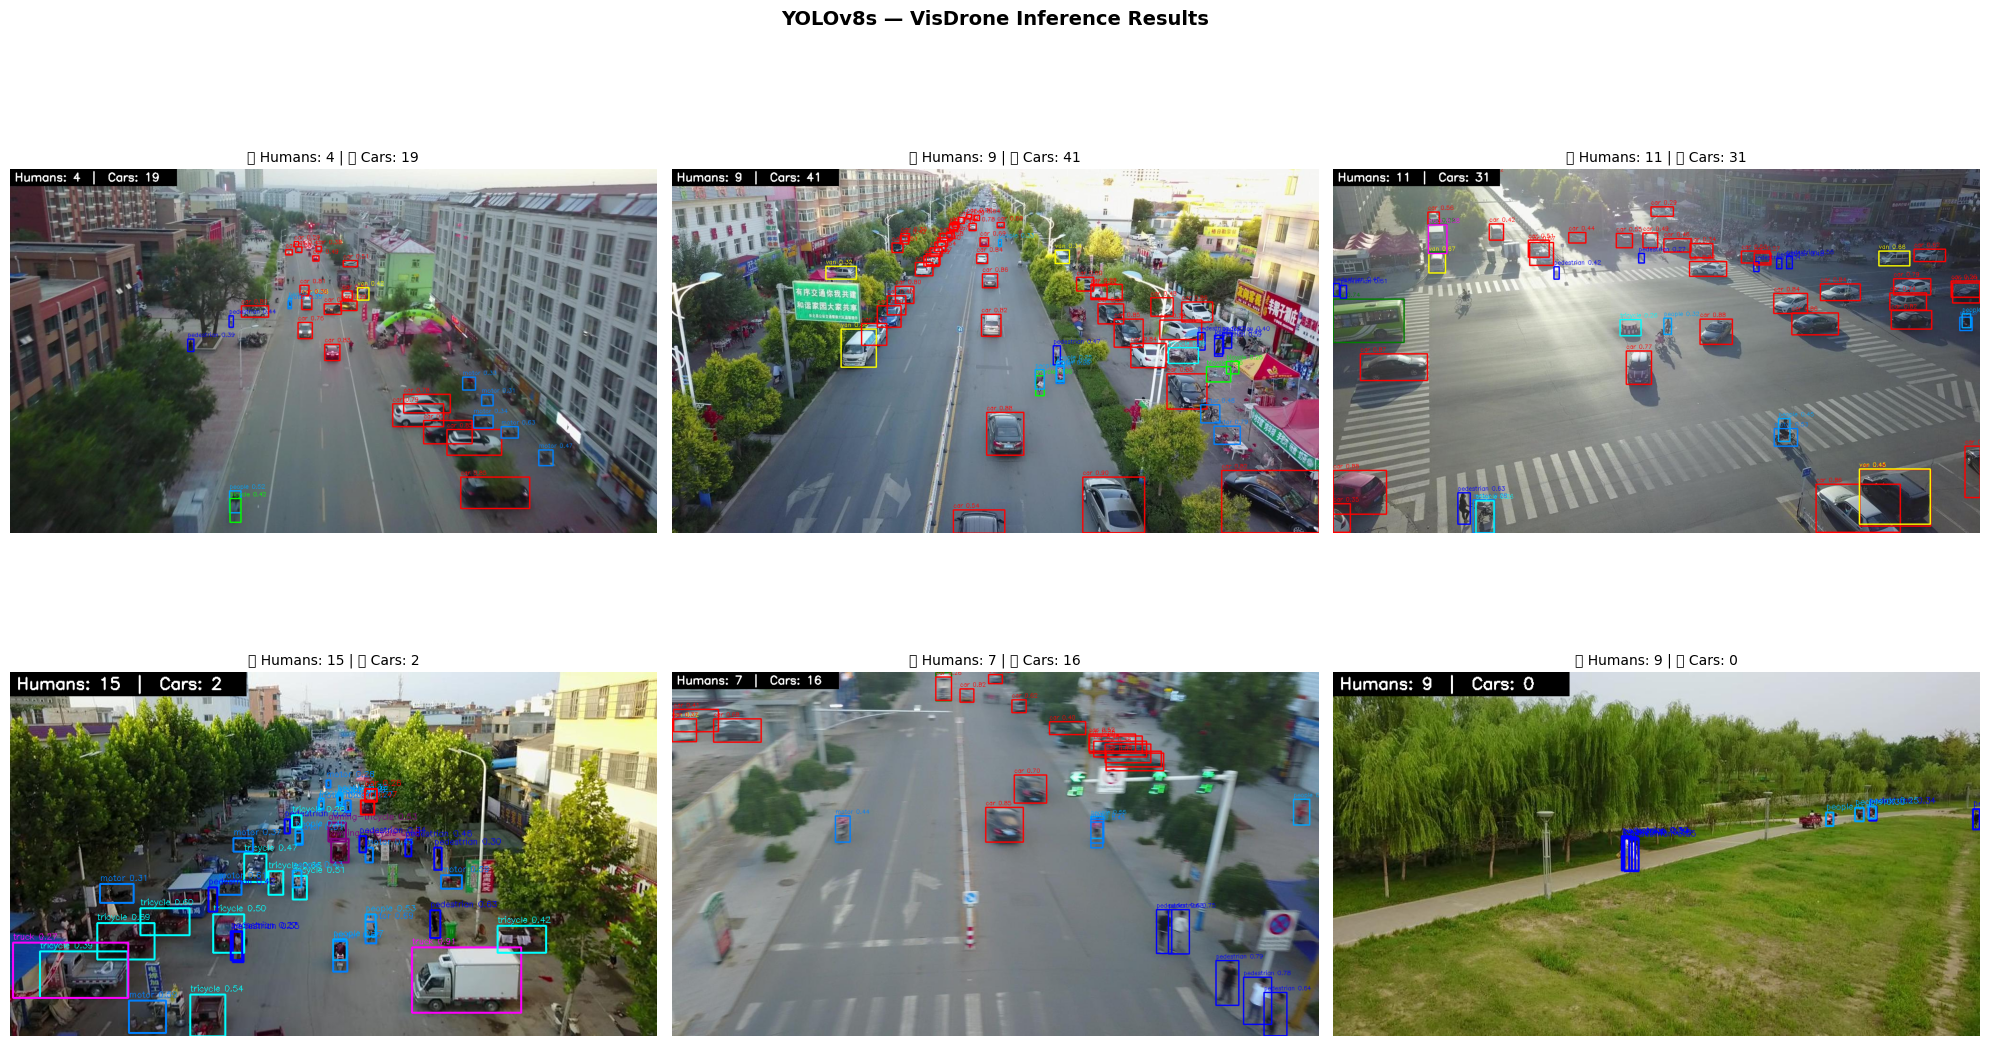

✅ Saved inference_results.png


In [4]:
# === DISPLAY 6 RESULTS ===
sample_imgs = random.sample(val_images, 6)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, img_name in enumerate(sample_imgs):
    annotated, humans, cars = run_inference_and_count(img_name)
    axes[i].imshow(annotated)
    axes[i].set_title(f"👤 Humans: {humans} | 🚗 Cars: {cars}", fontsize=10)
    axes[i].axis('off')

plt.suptitle('YOLOv8s — VisDrone Inference Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/inference_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved inference_results.png")

In [5]:
# === BATCH COUNTING ON 50 IMAGES ===
print("📊 Running batch inference on 50 val images...")

total_humans = 0
total_cars = 0

for img_name in val_images[:50]:
    _, humans, cars = run_inference_and_count(img_name)
    total_humans += humans
    total_cars += cars

print(f"\n✅ Results over 50 validation images:")
print(f"  Total humans detected : {total_humans}")
print(f"  Total cars detected   : {total_cars}")
print(f"  Avg humans per image  : {total_humans/50:.1f}")
print(f"  Avg cars per image    : {total_cars/50:.1f}")

📊 Running batch inference on 50 val images...

✅ Results over 50 validation images:
  Total humans detected : 1113
  Total cars detected   : 450
  Avg humans per image  : 22.3
  Avg cars per image    : 9.0


In [6]:
# === STEP 5: FORMAL EVALUATION ===
import yaml

custom_yaml = {
    'path': "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset",
    'train': 'VisDrone2019-DET-train/images',
    'val': 'VisDrone2019-DET-val/images',
    'test': 'VisDrone2019-DET-test-dev/images',
    'nc': 10,
    'names': {
        0: 'pedestrian', 1: 'people', 2: 'bicycle',
        3: 'car', 4: 'van', 5: 'truck',
        6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'
    }
}

yaml_path = '/kaggle/working/visdrone_custom.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(custom_yaml, f, default_flow_style=False)

metrics = model.val(data=yaml_path, verbose=True)

print(f"\n📊 FINAL EVALUATION METRICS:")
print(f"  mAP50       : {metrics.box.map50:.3f}")
print(f"  mAP50-95    : {metrics.box.map:.3f}")
print(f"  Precision   : {metrics.box.mp:.3f}")
print(f"  Recall      : {metrics.box.mr:.3f}")

Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 36.9±45.6 MB/s, size: 132.3 KB)
val: Scanning /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val/labels... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 187.1it/s 2.9s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 4.5s/it 2:38
                   all        548      38759      0.497      0.384      0.372      0.216
            pedestrian        520       8844      0.482      0.427      0.402      0.176
                people        482       5125      0.539      0.277      0.293      0.102
               bicycle        364       1287      0.252      0.177      0.118     0.0469
  

/tmp/ipykernel_16/1737986282.py:13: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/1737986282.py:13: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16/1737986282.py:14: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/final_results.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_16/1737986282.py:14: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.savefig('/kaggle/working/final_results.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from f

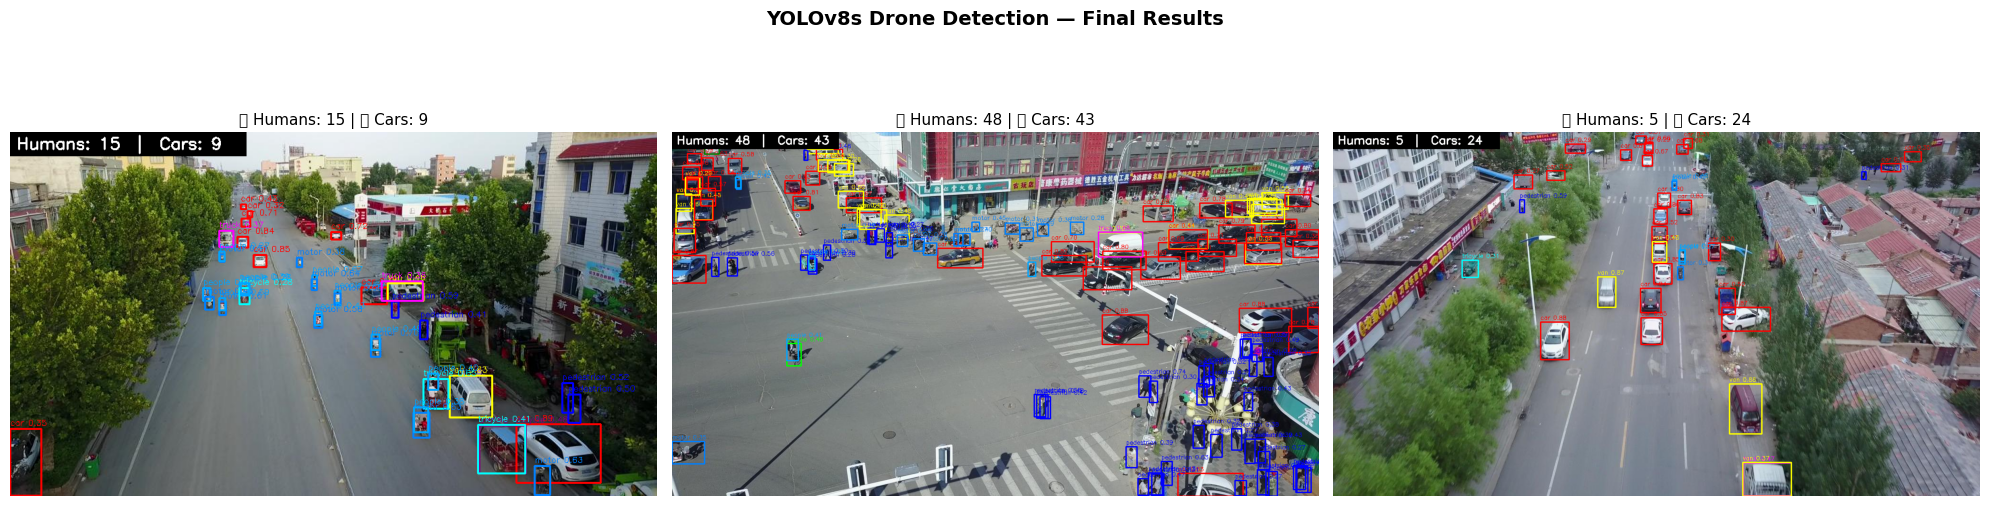

✅ Saved final_results.png


In [7]:
# === FINAL SUMMARY VISUALIZATION ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Show 3 good inference results
sample_imgs = random.sample(val_images, 3)
for i, img_name in enumerate(sample_imgs):
    annotated, humans, cars = run_inference_and_count(img_name)
    axes[i].imshow(annotated)
    axes[i].set_title(f"👤 Humans: {humans} | 🚗 Cars: {cars}", fontsize=11)
    axes[i].axis('off')

plt.suptitle('YOLOv8s Drone Detection — Final Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved final_results.png")

In [8]:
!pip install sahi ultralytics -q
print("✅ Done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.2 MB/s eta 0:00:00
✅ Done


In [9]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os, random

base = "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset"
val_img_path = f"{base}/VisDrone2019-DET-val/images"
val_images = sorted(os.listdir(val_img_path))

# Load model through SAHI
detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model_path='/kaggle/input/datasets/mdtanzimqaiyum/visdrone-yolov8s-weights/best.pt',
    confidence_threshold=0.25,
    device='cuda')
print("✅ SAHI model loaded")

✅ SAHI model loaded


In [10]:
# Pick one image
img_name = random.choice(val_images)
img_path = os.path.join(val_img_path, img_name)

# Run sliced prediction
result = get_sliced_prediction(
    img_path,
    detection_model,
    slice_height=320,
    slice_width=320,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
    verbose=0
)

print(f"Image: {img_name}")
print(f"Total detections with SAHI: {len(result.object_prediction_list)}")

Image: 0000327_02601_d_0000724.jpg
Total detections with SAHI: 80


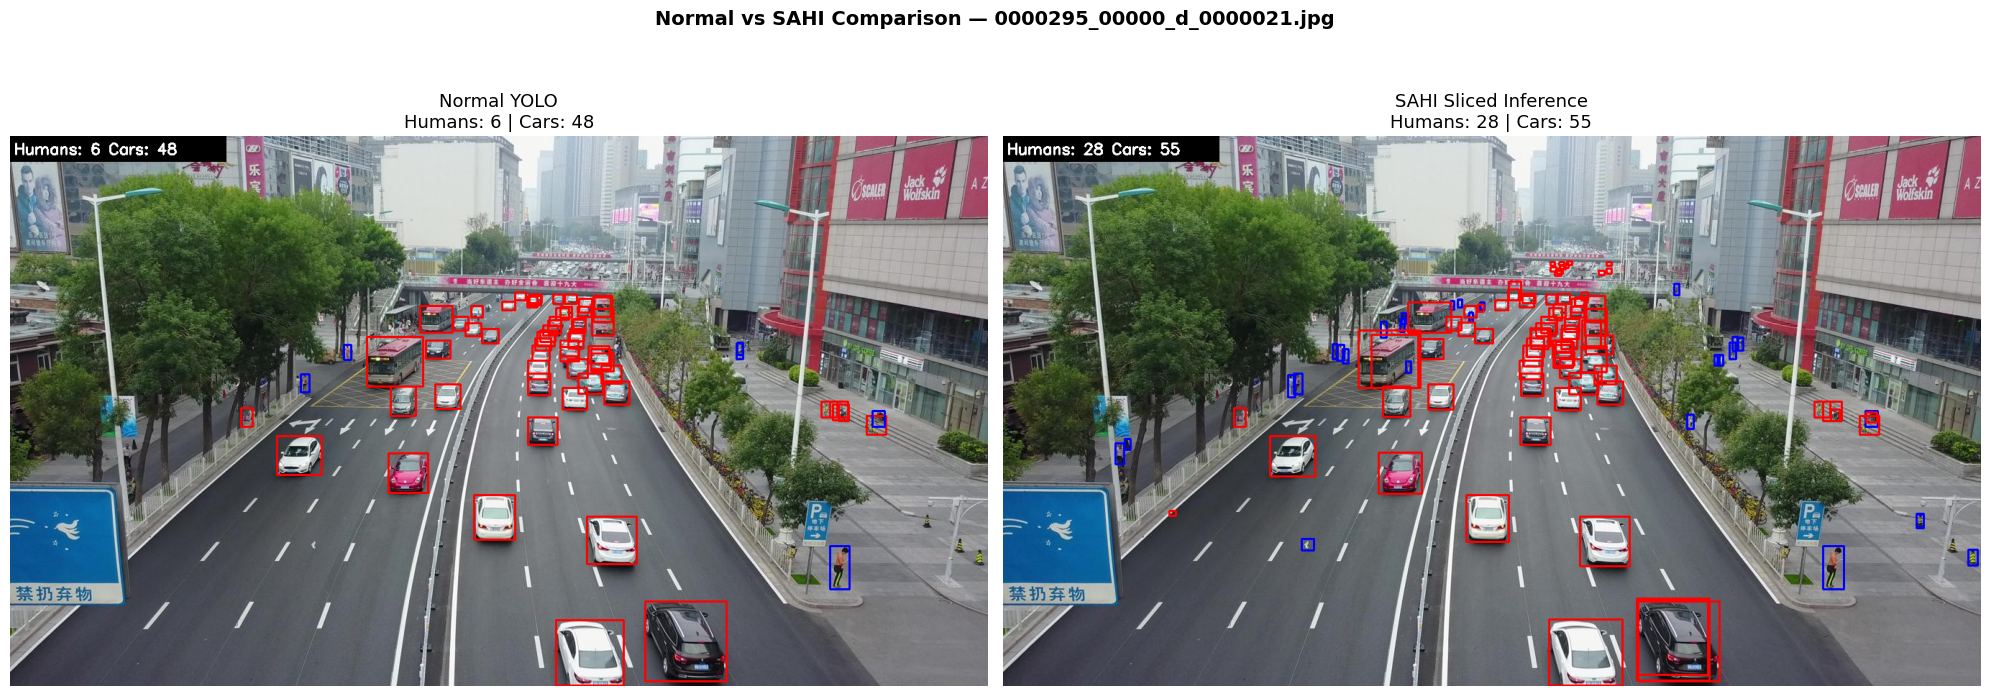


📊 Improvement:
  Humans — Normal: 6 → SAHI: 28 (+22)
  Cars   — Normal: 48 → SAHI: 55 (+7)


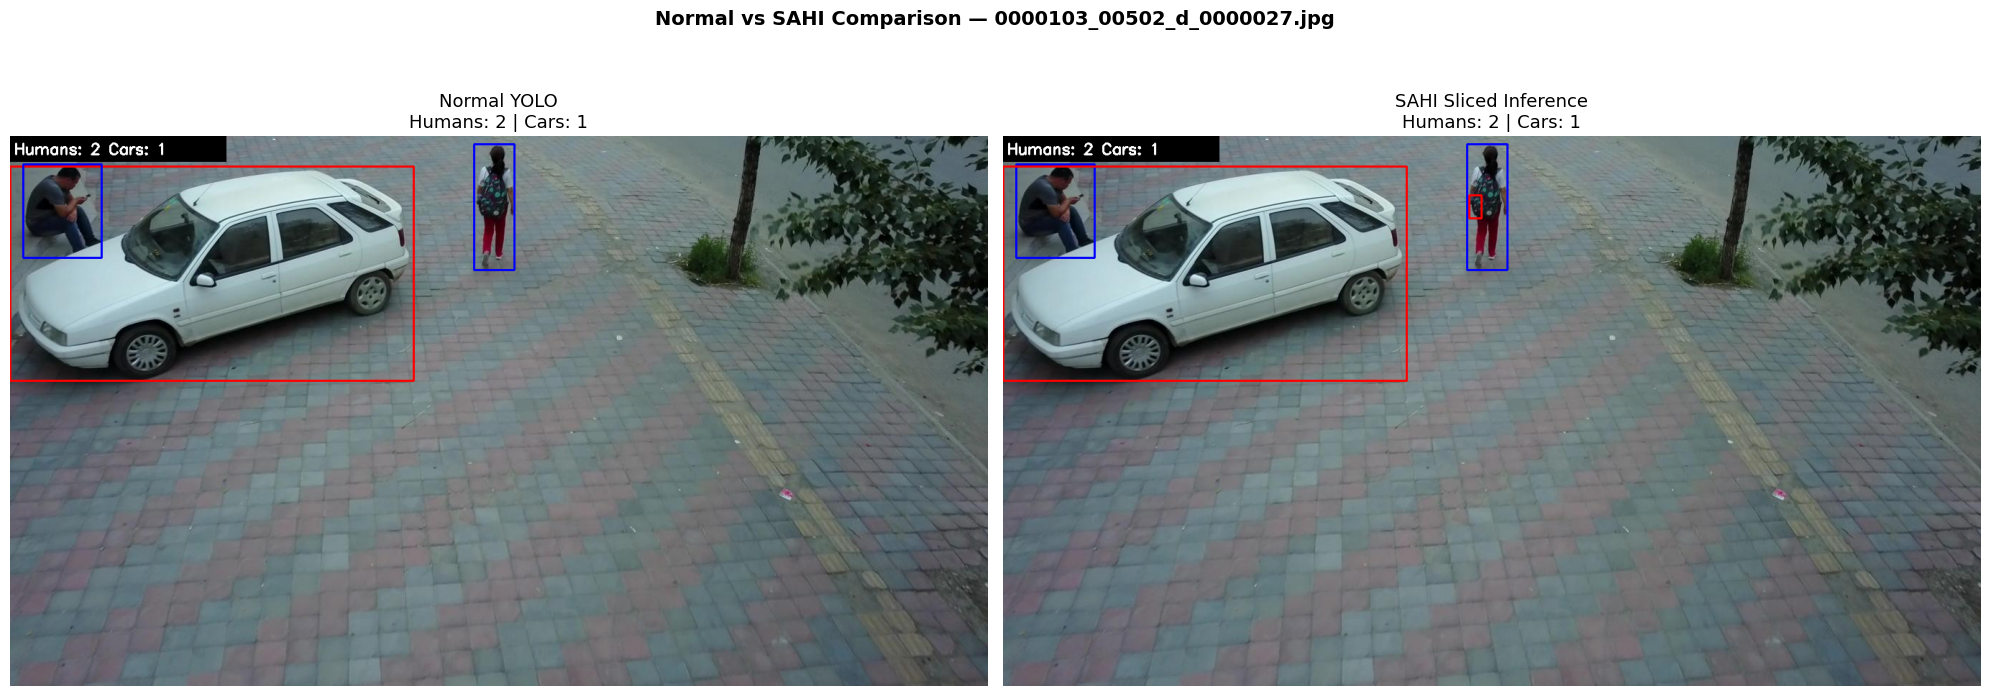


📊 Improvement:
  Humans — Normal: 2 → SAHI: 2 (+0)
  Cars   — Normal: 1 → SAHI: 1 (+0)


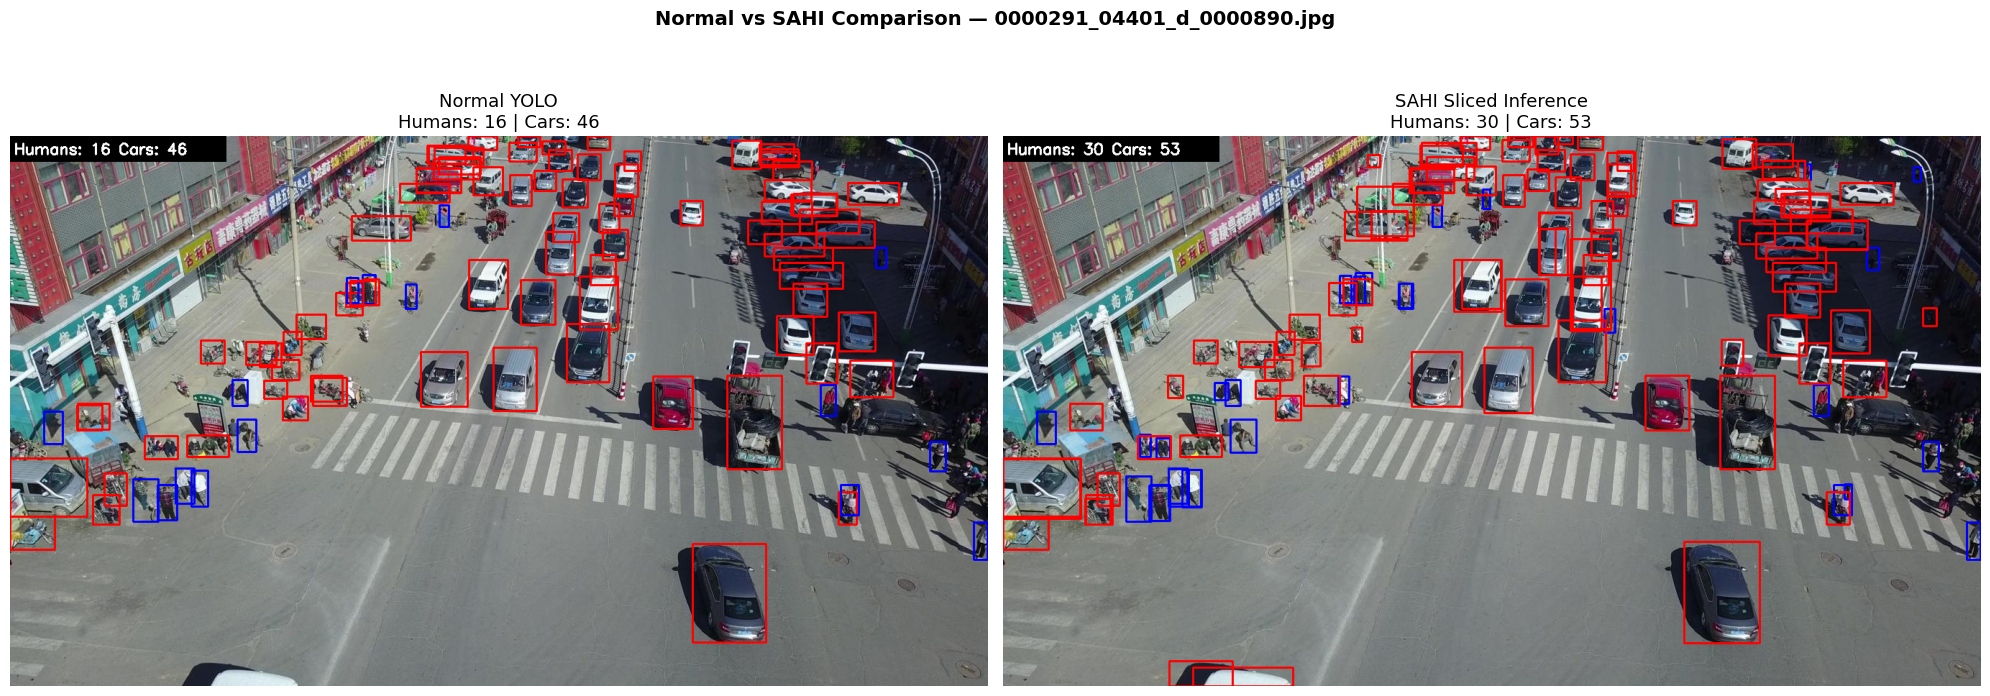


📊 Improvement:
  Humans — Normal: 16 → SAHI: 30 (+14)
  Cars   — Normal: 46 → SAHI: 53 (+7)


In [11]:
from ultralytics import YOLO
import numpy as np

model = YOLO('/kaggle/input/datasets/mdtanzimqaiyum/visdrone-yolov8s-weights/best.pt')

CLASSES = {
    0: 'pedestrian', 1: 'people', 2: 'bicycle',
    3: 'car', 4: 'van', 5: 'truck',
    6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'
}

def compare_sahi_vs_normal(img_name):
    img_path = os.path.join(val_img_path, img_name)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- NORMAL INFERENCE ---
    normal_result = model(img_path, conf=0.25, verbose=False)[0]
    normal_img = img_rgb.copy()
    normal_humans = 0
    normal_cars = 0

    for box in normal_result.boxes:
        cls = int(box.cls[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color = (255, 0, 0) if cls == 3 else (255, 0, 0) if cls in [0,1] else (0, 255, 0)
        cv2.rectangle(normal_img, (x1, y1), (x2, y2),
                     (0, 0, 255) if cls in [0,1] else (255, 0, 0), 2)
        if cls in [0, 1]: normal_humans += 1
        elif cls == 3: normal_cars += 1

    cv2.rectangle(normal_img, (0, 0), (300, 35), (0,0,0), -1)
    cv2.putText(normal_img, f"Humans: {normal_humans} Cars: {normal_cars}",
                (5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    # --- SAHI INFERENCE ---
    sahi_result = get_sliced_prediction(
        img_path, detection_model,
        slice_height=320, slice_width=320,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        verbose=0
    )
    sahi_img = img_rgb.copy()
    sahi_humans = 0
    sahi_cars = 0

    for pred in sahi_result.object_prediction_list:
        cls = pred.category.id
        bbox = pred.bbox
        x1, y1, x2, y2 = int(bbox.minx), int(bbox.miny), int(bbox.maxx), int(bbox.maxy)
        cv2.rectangle(sahi_img, (x1, y1), (x2, y2),
                     (0, 0, 255) if cls in [0,1] else (255, 0, 0), 2)
        if cls in [0, 1]: sahi_humans += 1
        elif cls == 3: sahi_cars += 1

    cv2.rectangle(sahi_img, (0, 0), (300, 35), (0,0,0), -1)
    cv2.putText(sahi_img, f"Humans: {sahi_humans} Cars: {sahi_cars}",
                (5, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

    # --- PLOT ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    axes[0].imshow(normal_img)
    axes[0].set_title(f"Normal YOLO\nHumans: {normal_humans} | Cars: {normal_cars}", fontsize=13)
    axes[0].axis('off')

    axes[1].imshow(sahi_img)
    axes[1].set_title(f"SAHI Sliced Inference\nHumans: {sahi_humans} | Cars: {sahi_cars}", fontsize=13)
    axes[1].axis('off')

    plt.suptitle(f'Normal vs SAHI Comparison — {img_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/sahi_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n📊 Improvement:")
    print(f"  Humans — Normal: {normal_humans} → SAHI: {sahi_humans} (+{sahi_humans - normal_humans})")
    print(f"  Cars   — Normal: {normal_cars} → SAHI: {sahi_cars} (+{sahi_cars - normal_cars})")

# Run on 3 random images
for img_name in random.sample(val_images, 3):
    compare_sahi_vs_normal(img_name)

In [12]:
print("📊 Batch comparison — Normal vs SAHI (20 images)...")

normal_total_humans = 0
sahi_total_humans = 0

for img_name in val_images[:20]:
    img_path = os.path.join(val_img_path, img_name)

    # Normal
    normal_result = model(img_path, conf=0.25, verbose=False)[0]
    normal_humans = sum(1 for box in normal_result.boxes if int(box.cls[0]) in [0,1])

    # SAHI
    sahi_result = get_sliced_prediction(
        img_path, detection_model,
        slice_height=320, slice_width=320,
        overlap_height_ratio=0.2, overlap_width_ratio=0.2,
        verbose=0
    )
    sahi_humans = sum(1 for pred in sahi_result.object_prediction_list
                      if pred.category.id in [0,1])

    normal_total_humans += normal_humans
    sahi_total_humans += sahi_humans

improvement = ((sahi_total_humans - normal_total_humans) / normal_total_humans) * 100

print(f"\n✅ Results over 20 images:")
print(f"  Normal YOLO total humans : {normal_total_humans}")
print(f"  SAHI total humans        : {sahi_total_humans}")
print(f"  Improvement              : +{improvement:.1f}%")

📊 Batch comparison — Normal vs SAHI (20 images)...

✅ Results over 20 images:
  Normal YOLO total humans : 351
  SAHI total humans        : 642
  Improvement              : +82.9%


In [13]:
import yaml

custom_yaml = {
    'path': "/kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset",
    'train': 'VisDrone2019-DET-train/images',
    'val': 'VisDrone2019-DET-val/images',
    'test': 'VisDrone2019-DET-test-dev/images',
    'nc': 10,
    'names': {
        0: 'pedestrian', 1: 'people', 2: 'bicycle',
        3: 'car', 4: 'van', 5: 'truck',
        6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'
    }
}

yaml_path = '/kaggle/working/visdrone_custom.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(custom_yaml, f, default_flow_style=False)

# Evaluate on TEST set
print("📊 Evaluating on TEST set...")
test_metrics = model.val(data=yaml_path, split='test', verbose=True)

print(f"\n✅ TEST SET RESULTS:")
print(f"  mAP50     : {test_metrics.box.map50:.3f}")
print(f"  mAP50-95  : {test_metrics.box.map:.3f}")
print(f"  Precision : {test_metrics.box.mp:.3f}")
print(f"  Recall    : {test_metrics.box.mr:.3f}")

📊 Evaluating on TEST set...
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 16.3±3.9 MB/s, size: 138.4 KB)
val: Scanning /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/labels... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 147.7it/s 10.9s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/banuprasadb/visdrone-dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 4.4s/it 7:28
                   all       1610      75102      0.432      0.344      0.309      0.176
            pedestrian       1197      21006      0.413      0.288      0.252     0.0982
                people        797       6376       0.47      0.115      0.126     0.0407
               bicycle        377       1302    